## Somatic Mutations — `6_OmicsSomaticMutationsProfile.csv`

Over 1 million mutation rows across cancer cell lines, keyed by DepMap `ProfileID`. Key signal columns: `HessDriver` (marks cancer-driving mutations) and `VepImpact` (damage severity — HIGH/MODERATE/LOW). Use `HessDriver=True` to identify oncogene driver mutations — `OncogeneHighImpact` misses hotspot mutations like KRAS G12 because they are classed as MODERATE by VEP.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
%%time
df = pd.read_csv(ini.df6, low_memory=False)

CPU times: total: 9.08 s
Wall time: 9.36 s


In [3]:
df.shape

(1066869, 70)

In [4]:
df.head()

,Chrom,Pos,Ref,Alt,AF,DP,RefCount,AltCount,GT,PS,...,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,RescueReason,ProfileID,Hotspot,EntrezGeneID
0,chr1,818203,G,A,0.240,27,21,6,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-t8SaQo,False,400728.0
1,chr1,851926,G,A,0.158,17,15,2,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-lhMBt6,False,643837.0
2,chr1,924510,GC,AA,0.412,35,21,14,0|1,924510.0,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-uKiczK,False,148398.0
3,chr1,924657,C,G,0.437,17,9,8,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-sxFiuq,False,148398.0
4,chr1,924750,C,T,0.625,19,7,12,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-DNEoiz,False,148398.0


In [5]:
print(df.loc[0].to_string())

Chrom                                                                           chr1
Pos                                                                           818203
Ref                                                                                G
Alt                                                                                A
AF                                                                              0.24
DP                                                                                27
RefCount                                                                          21
AltCount                                                                           6
GT                                                                               0/1
PS                                                                               NaN
VariantType                                                                      SNV
VariantInfo                        splice_donor_variant&non_codin

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1066869 entries, 0 to 1066868
Data columns (total 70 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Chrom                            1066869 non-null  str    
 1   Pos                              1066869 non-null  int64  
 2   Ref                              1066869 non-null  str    
 3   Alt                              1066869 non-null  str    
 4   AF                               1066869 non-null  float64
 5   DP                               1066869 non-null  int64  
 6   RefCount                         1066869 non-null  int64  
 7   AltCount                         1066869 non-null  int64  
 8   GT                               1066869 non-null  str    
 9   PS                               67917 non-null    float64
 10  VariantType                      1066869 non-null  str    
 11  VariantInfo                      1066869 non-null  str    
 1

### Missing value analysis
Half the 70 columns are nearly empty. The chart below shows which to drop.

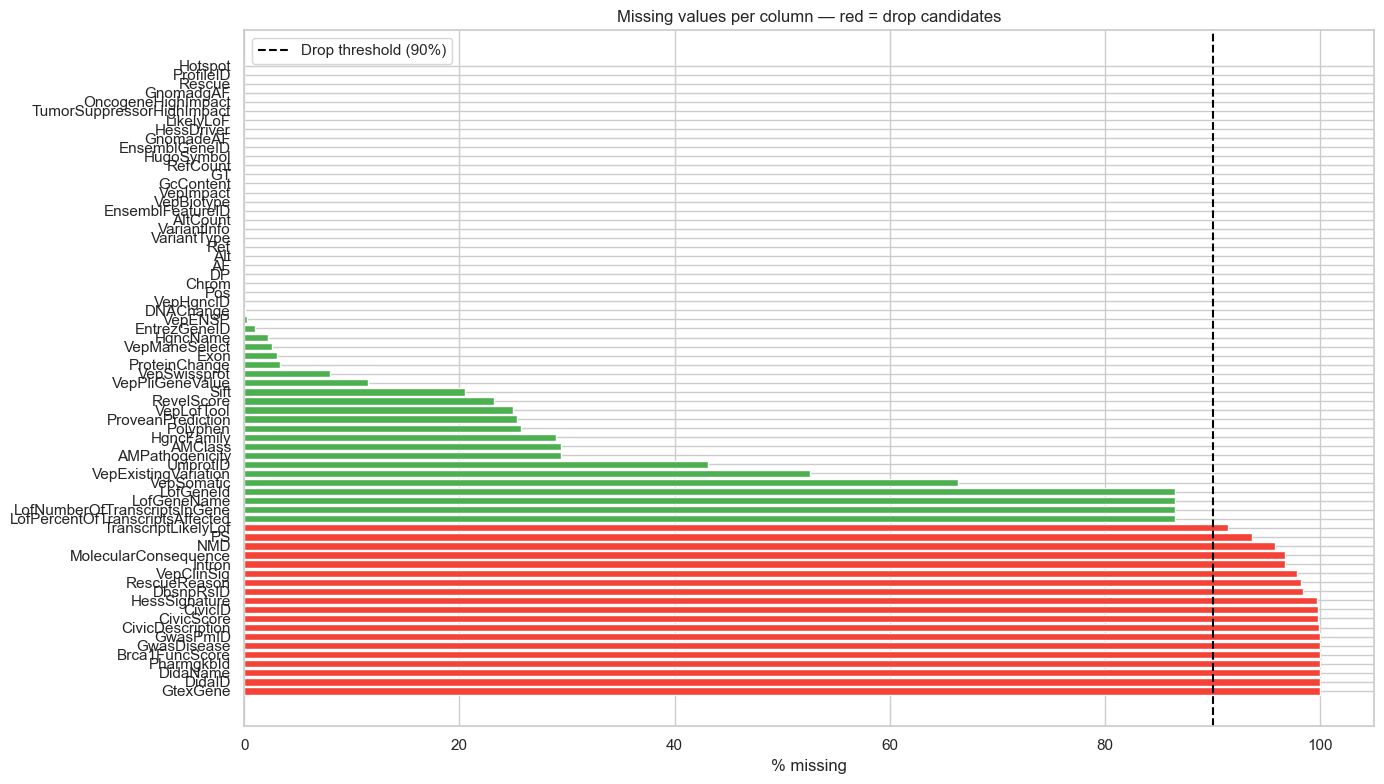

Columns to drop (≥90% missing): 19
['GtexGene', 'DidaID', 'DidaName', 'PharmgkbId', 'Brca1FuncScore', 'GwasDisease', 'GwasPmID', 'CivicDescription', 'CivicScore', 'CivicID', 'HessSignature', 'DbsnpRsID', 'RescueReason', 'VepClinSig', 'Intron', 'MolecularConsequence', 'NMD', 'PS', 'TranscriptLikelyLof']


In [7]:
pct_miss = df.isnull().mean().sort_values(ascending=False) * 100
keep_threshold = 90

fig, ax = plt.subplots(figsize=(14, 8))
colors = ["#F44336" if v >= keep_threshold else "#4CAF50" for v in pct_miss.values]
ax.barh(pct_miss.index, pct_miss.values, color=colors)
ax.axvline(keep_threshold, color="black", linestyle="--", label=f"Drop threshold ({keep_threshold}%)")
ax.set_xlabel("% missing"); ax.set_title("Missing values per column — red = drop candidates")
ax.legend(); plt.tight_layout(); plt.show()

drop_cols = pct_miss[pct_miss >= keep_threshold].index.tolist()
print(f"Columns to drop (≥{keep_threshold}% missing): {len(drop_cols)}")
print(drop_cols)


### Mutation burden per cell line
The distribution is right-skewed: most cell lines have a few thousand mutations; a small fraction are hypermutators.

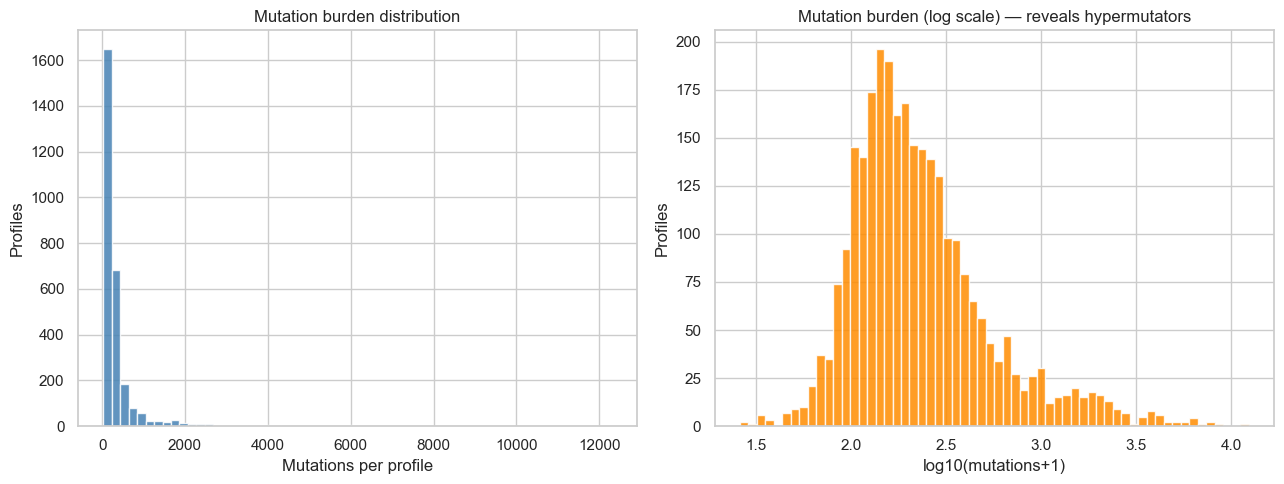

Median mutations/profile: 194
Hypermutators (>10k muts): 1


In [8]:
burden = df.groupby("ProfileID").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(burden, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Mutations per profile"); axes[0].set_ylabel("Profiles")
axes[0].set_title("Mutation burden distribution")

axes[1].hist(np.log10(burden+1), bins=60, color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log10(mutations+1)"); axes[1].set_ylabel("Profiles")
axes[1].set_title("Mutation burden (log scale) — reveals hypermutators")

plt.tight_layout(); plt.show()
print(f"Median mutations/profile: {burden.median():.0f}")
print(f"Hypermutators (>10k muts): {(burden>10000).sum()}")


### VepImpact distribution
VEP classifies mutations by predicted damage. HIGH = loss-of-function; MODERATE = missense. **Note:** this file is pre-filtered to coding-impactful variants, so the panel is ~84% MODERATE (missense) and ~16% HIGH, with LOW/MODIFIER essentially absent (only ~39 LOW rows in 1.07M). So most calls here are moderate-impact missense, NOT low-impact.

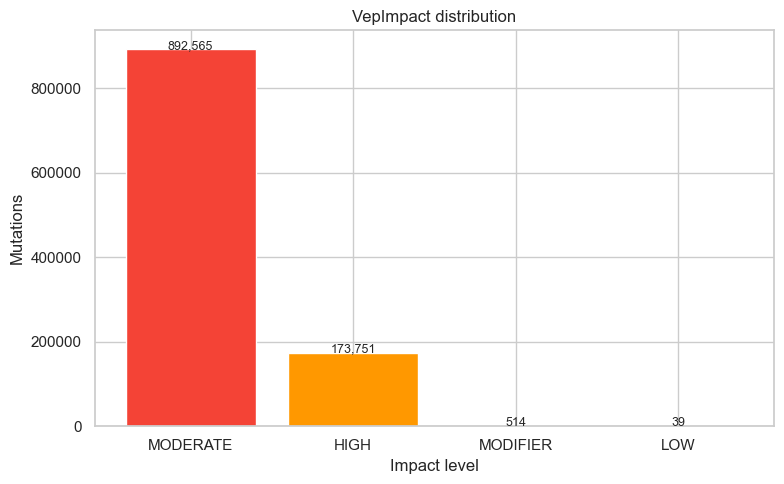

In [9]:
vep = df["VepImpact"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(vep.index, vep.values,
       color=["#F44336", "#FF9800", "#FFC107", "#4CAF50"][:len(vep)])
ax.set_title("VepImpact distribution")
ax.set_ylabel("Mutations"); ax.set_xlabel("Impact level")
for bar, val in zip(ax.patches, vep.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
            f"{val:,}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


### Most mutated genes
Top genes by raw mutation count — these are either true drivers or large genes that accumulate passenger mutations.

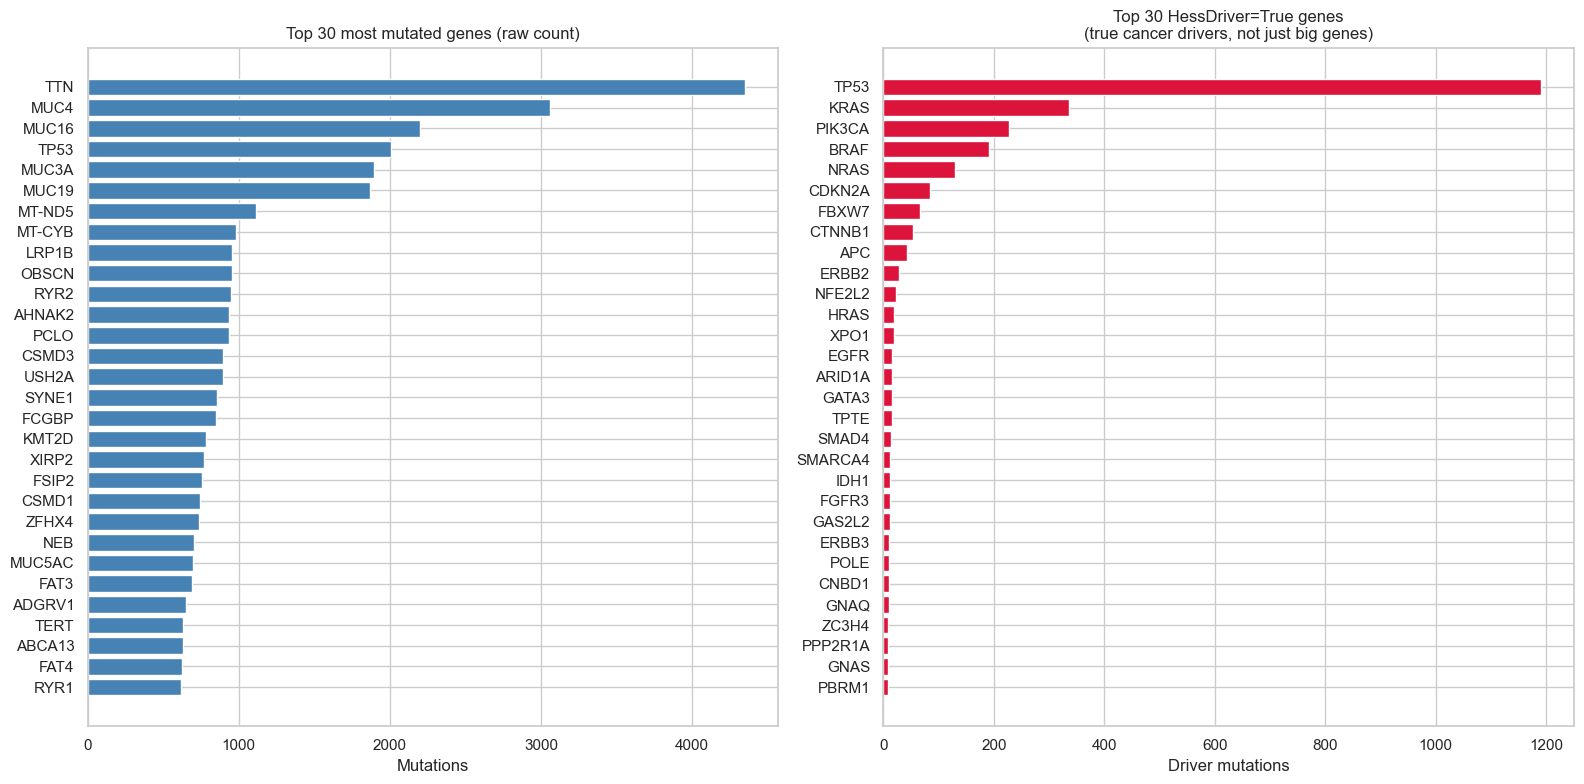

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_genes = df["HugoSymbol"].value_counts().head(30)
axes[0].barh(top_genes.index[::-1], top_genes.values[::-1], color="steelblue")
axes[0].set_title("Top 30 most mutated genes (raw count)")
axes[0].set_xlabel("Mutations")

# HessDriver = True only
drivers = df[df["HessDriver"] == True]["HugoSymbol"].value_counts().head(30)
axes[1].barh(drivers.index[::-1], drivers.values[::-1], color="crimson")
axes[1].set_title("Top 30 HessDriver=True genes\n(true cancer drivers, not just big genes)")
axes[1].set_xlabel("Driver mutations")

plt.tight_layout(); plt.show()


### Functional flag breakdown
Shows the proportion of mutations that are functionally significant across the different annotation systems.

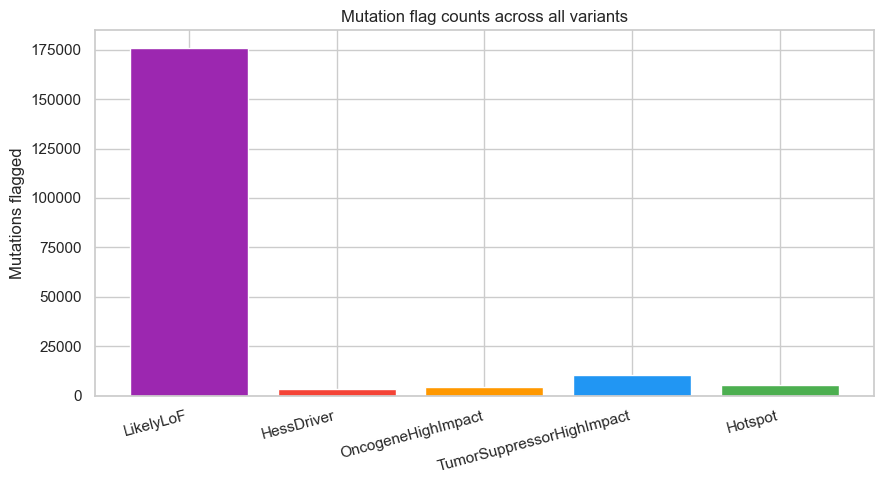

In [11]:
flags = {
    "LikelyLoF"               : df["LikelyLoF"].sum(),
    "HessDriver"               : df["HessDriver"].sum(),
    "OncogeneHighImpact"       : df["OncogeneHighImpact"].sum(),
    "TumorSuppressorHighImpact": df["TumorSuppressorHighImpact"].sum(),
    "Hotspot"                  : df["Hotspot"].sum(),
}
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(flags.keys(), flags.values(), color=["#9C27B0","#F44336","#FF9800","#2196F3","#4CAF50"])
ax.set_title("Mutation flag counts across all variants")
ax.set_ylabel("Mutations flagged")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()


### Chromosome distribution
Uniform-ish distribution expected. Large deviations may reflect chromosomal instability.

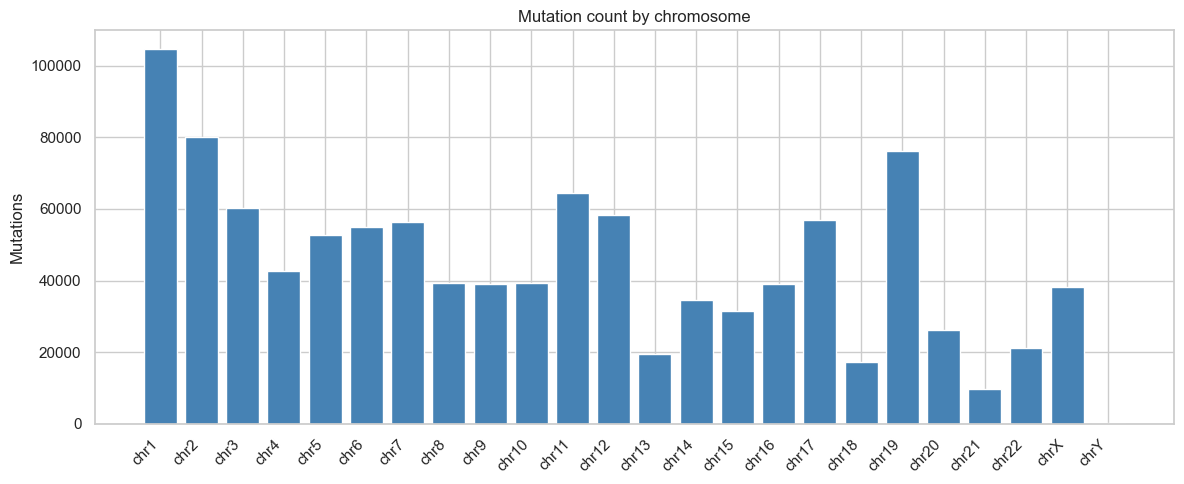

In [12]:
chrom_order = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
chrom_counts = df["Chrom"].value_counts().reindex(chrom_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(chrom_counts.index, chrom_counts.values, color="steelblue")
ax.set_title("Mutation count by chromosome")
ax.set_ylabel("Mutations"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


### Key findings

In [13]:
print("=== Somatic Mutations ===")
print(f"Total mutations         : {len(df):,}")
print(f"Unique ProfileIDs       : {df['ProfileID'].nunique()}")
print(f"Median burden/profile   : {burden.median():.0f}")
print(f"Hypermutators (>10k)    : {(burden>10000).sum()}")
print(f"HessDriver=True         : {df['HessDriver'].sum():,} ({df['HessDriver'].mean()*100:.2f}%)")
print(f"Columns to drop (≥90%NaN): {len(drop_cols)}")


=== Somatic Mutations ===
Total mutations         : 1,066,869
Unique ProfileIDs       : 2828
Median burden/profile   : 194
Hypermutators (>10k)    : 1
HessDriver=True         : 3,530 (0.33%)
Columns to drop (≥90%NaN): 19


## Join Analysis — how this table connects to the others

df6 uses **ProfileID** (WES or WGS) — same as df2 but for a different assay type.
It joins to df9 via df8, and to df2 via the shared ModelID after resolution.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df6 | `ProfileID` | df8 | `ProfileID` (wes/wgs) | 1:1 | bridge |
| df8 | `ModelID` | df9 | `DepMap_ID` | 1:1 | metadata |
| df6 via df9 | ModelID | df2 via df9 | ModelID | 1:1 | mutations + RNA |
| df6 via df9 | ModelID | df5 | `ModelID` | 1:many | mutations + fusions |

**Biological note:** One ModelID can have BOTH a WES and a WGS ProfileID in df6.
WGS gives higher mutation sensitivity; WES is more targeted. Using `IsDefaultEntry`
flags from df8 selects the canonical profile per cell line.


In [14]:
# ── A/B: Join coverage df6 → df8 → df9 ─────────────────────────────────────
df8_ids = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])
df9_ids = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage"])

mut_profiles  = set(df["ProfileID"].dropna().unique())    # df6 ProfileID column
df8_nonrna    = df8_ids[df8_ids["Datatype"].isin(["wes","wgs"])]
df8_profs     = set(df8_nonrna["ProfileID"])
matched_profs = mut_profiles & df8_profs
lost_profs    = mut_profiles - df8_profs

resolved_models = set(df8_nonrna[df8_nonrna["ProfileID"].isin(matched_profs)]["ModelID"])
df9_models      = set(df9_ids["DepMap_ID"])
matched_models  = resolved_models & df9_models
lost_models     = resolved_models - df9_models

# How many ModelIDs have BOTH wes and wgs in df6?
model_types = df8_nonrna[df8_nonrna["ProfileID"].isin(matched_profs)].groupby("ModelID")["Datatype"].apply(set)
both_wes_wgs = (model_types.apply(lambda s: "wes" in s and "wgs" in s)).sum()

print("=== df6 join: ProfileID → df8(wes/wgs) → df9 ===")
print(f"df6 unique ProfileIDs           : {len(mut_profiles)}")
print(f"Matched in df8 (wes/wgs)        : {len(matched_profs)} ({len(matched_profs)/len(mut_profiles)*100:.1f}%)")
print(f"Lost ProfileIDs (not in df8)    : {len(lost_profs)}")
print(f"Resolved unique ModelIDs        : {len(resolved_models)}")
print(f"ModelIDs matched in df9         : {len(matched_models)} ({len(matched_models)/len(resolved_models)*100:.1f}%)")
print(f"Lost ModelIDs (not in df9)      : {len(lost_models)}")
print(f"ModelIDs with BOTH wes+wgs      : {both_wes_wgs}")


=== df6 join: ProfileID → df8(wes/wgs) → df9 ===
df6 unique ProfileIDs           : 2828
Matched in df8 (wes/wgs)        : 2329 (82.4%)
Lost ProfileIDs (not in df8)    : 499
Resolved unique ModelIDs        : 1744
ModelIDs matched in df9         : 1697 (97.3%)
Lost ModelIDs (not in df9)      : 47
ModelIDs with BOTH wes+wgs      : 377


In [15]:
# ── C: Format check on ProfileID in df6 ─────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["ProfileID"].dropna(), "ProfileID (df6)", prefix="PR-")
print()
# Data consistency: check DtypeWarning columns for mixed types
dtype_warn_cols = ["DbsnpRsID", "CivicDescription", "HessSignature",
                   "PharmgkbId", "DidaID", "DidaName", "GwasDisease", "GtexGene"]
print("Mixed-type column sample values (first non-null per column):")
for col in dtype_warn_cols:
    if col in df.columns:
        first_val = df[col].dropna().iloc[0] if df[col].notna().any() else "all NaN"
        print(f"  {col:30s}: {repr(first_val)[:60]}")


Format check — ProfileID (df6) (n=1066869 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'PR-'  : True
  Length range        : 9 – 9


  Duplicates          : 1064041

Mixed-type column sample values (first non-null per column):
  DbsnpRsID                     : '752746786.0'
  CivicDescription              : 'NRAS Q61 mutations have been found in multiple myeloma, gas
  HessSignature                 : 'POLE:5,Misc:3'
  PharmgkbId                    : 'PA166154663'
  DidaID                        : 'dd227'
  DidaName                      : 'CANDLE syndrome'
  GwasDisease                   : 'Reduced foot dorsiflexion strength in Charcot-Marie-Tooth d
  GtexGene                      : 'ENSG00000127328.17|ENSG00000127328.17'


### Biological implications

ProfileIDs in df6 that are not in df8 represent mutation calls from a non-standard
or legacy sequencing run — they cannot be mapped to a cell line.

Cell lines with BOTH WES and WGS sequencing are the highest-quality entries: WGS
provides whole-genome mutation calls (including non-coding regions), while WES
targets coding genes more deeply. For the CellLineSelector pipeline, using the
'default' (highest-quality) profile per cell line is the correct approach.


In [16]:
# Biological: lineage coverage of mutation data
mut_df9 = df9_ids[df9_ids["DepMap_ID"].isin(matched_models)]
no_mut  = df9_ids[~df9_ids["DepMap_ID"].isin(matched_models)]

print("Lineages WITH mutation data (top 10):")
print(mut_df9["lineage"].value_counts().head(10).to_string())
print()
print("df9 lineages WITHOUT mutation data (top 10):")
print(no_mut["lineage"].value_counts().head(10).to_string())
print()
total_per = df9_ids["lineage"].value_counts()
mut_per   = mut_df9["lineage"].value_counts()
pct = (mut_per / total_per * 100).dropna().sort_values()
print("Mutation coverage % per lineage (lowest first — potential bias):")
print(pct.head(10).round(1).to_string())


Lineages WITH mutation data (top 10):
lineage
lung                      253
blood                     134
skin                      109
lymphocyte                106
central_nervous_system    102
colorectal                 78
upper_aerodigestive        75
breast                     68
bone                       68
ovary                      68

df9 lineages WITHOUT mutation data (top 10):
lineage
lung                      21
breast                    18
fibroblast                15
bone                      11
skin                      11
kidney                     8
blood                      7
central_nervous_system     7
soft_tissue                7
colorectal                 7

Mutation coverage % per lineage (lowest first — potential bias):
lineage
fibroblast     64.3
breast         79.1
plasma_cell    85.7
bone           86.1
kidney         86.7
soft_tissue    90.1
skin           90.8
cervix         91.7
colorectal     91.8
ovary          91.9


## Join Analysis — how this table connects to the others

df6 uses **ProfileID** (WES or WGS) — same as df2 but for a different assay type.
It joins to df9 via df8, and to df2 via the shared ModelID after resolution.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df6 | `ProfileID` | df8 | `ProfileID` (wes/wgs) | 1:1 | bridge |
| df8 | `ModelID` | df9 | `DepMap_ID` | 1:1 | metadata |
| df6 via df9 | ModelID | df2 via df9 | ModelID | 1:1 | mutations + RNA |
| df6 via df9 | ModelID | df5 | `ModelID` | 1:many | mutations + fusions |

**Biological note:** One ModelID can have BOTH a WES and a WGS ProfileID in df6.
WGS gives higher mutation sensitivity; WES is more targeted. Using `IsDefaultEntry`
flags from df8 selects the canonical profile per cell line.


In [17]:
# ── A/B: Join coverage df6 → df8 → df9 ─────────────────────────────────────
df8_ids = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])
df9_ids = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage"])

mut_profiles  = set(df["ProfileID"].dropna().unique())    # df6 ProfileID column
df8_nonrna    = df8_ids[df8_ids["Datatype"].isin(["wes","wgs"])]
df8_profs     = set(df8_nonrna["ProfileID"])
matched_profs = mut_profiles & df8_profs
lost_profs    = mut_profiles - df8_profs

resolved_models = set(df8_nonrna[df8_nonrna["ProfileID"].isin(matched_profs)]["ModelID"])
df9_models      = set(df9_ids["DepMap_ID"])
matched_models  = resolved_models & df9_models
lost_models     = resolved_models - df9_models

# How many ModelIDs have BOTH wes and wgs in df6?
model_types = df8_nonrna[df8_nonrna["ProfileID"].isin(matched_profs)].groupby("ModelID")["Datatype"].apply(set)
both_wes_wgs = (model_types.apply(lambda s: "wes" in s and "wgs" in s)).sum()

print("=== df6 join: ProfileID → df8(wes/wgs) → df9 ===")
print(f"df6 unique ProfileIDs           : {len(mut_profiles)}")
print(f"Matched in df8 (wes/wgs)        : {len(matched_profs)} ({len(matched_profs)/len(mut_profiles)*100:.1f}%)")
print(f"Lost ProfileIDs (not in df8)    : {len(lost_profs)}")
print(f"Resolved unique ModelIDs        : {len(resolved_models)}")
print(f"ModelIDs matched in df9         : {len(matched_models)} ({len(matched_models)/len(resolved_models)*100:.1f}%)")
print(f"Lost ModelIDs (not in df9)      : {len(lost_models)}")
print(f"ModelIDs with BOTH wes+wgs      : {both_wes_wgs}")


=== df6 join: ProfileID → df8(wes/wgs) → df9 ===
df6 unique ProfileIDs           : 2828
Matched in df8 (wes/wgs)        : 2329 (82.4%)
Lost ProfileIDs (not in df8)    : 499
Resolved unique ModelIDs        : 1744
ModelIDs matched in df9         : 1697 (97.3%)
Lost ModelIDs (not in df9)      : 47
ModelIDs with BOTH wes+wgs      : 377


In [18]:
# ── C: Format check on ProfileID in df6 ─────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["ProfileID"].dropna(), "ProfileID (df6)", prefix="PR-")
print()
# Data consistency: check DtypeWarning columns for mixed types
dtype_warn_cols = ["DbsnpRsID", "CivicDescription", "HessSignature",
                   "PharmgkbId", "DidaID", "DidaName", "GwasDisease", "GtexGene"]
print("Mixed-type column sample values (first non-null per column):")
for col in dtype_warn_cols:
    if col in df.columns:
        first_val = df[col].dropna().iloc[0] if df[col].notna().any() else "all NaN"
        print(f"  {col:30s}: {repr(first_val)[:60]}")


Format check — ProfileID (df6) (n=1066869 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'PR-'  : True
  Length range        : 9 – 9
  Duplicates          : 1064041

Mixed-type column sample values (first non-null per column):
  DbsnpRsID                     : '752746786.0'


  CivicDescription              : 'NRAS Q61 mutations have been found in multiple myeloma, gas
  HessSignature                 : 'POLE:5,Misc:3'
  PharmgkbId                    : 'PA166154663'
  DidaID                        : 'dd227'
  DidaName                      : 'CANDLE syndrome'
  GwasDisease                   : 'Reduced foot dorsiflexion strength in Charcot-Marie-Tooth d
  GtexGene                      : 'ENSG00000127328.17|ENSG00000127328.17'


### Biological implications

ProfileIDs in df6 that are not in df8 represent mutation calls from a non-standard
or legacy sequencing run — they cannot be mapped to a cell line.

Cell lines with BOTH WES and WGS sequencing are the highest-quality entries: WGS
provides whole-genome mutation calls (including non-coding regions), while WES
targets coding genes more deeply. For the CellLineSelector pipeline, using the
'default' (highest-quality) profile per cell line is the correct approach.


In [19]:
# Biological: lineage coverage of mutation data
mut_df9 = df9_ids[df9_ids["DepMap_ID"].isin(matched_models)]
no_mut  = df9_ids[~df9_ids["DepMap_ID"].isin(matched_models)]

print("Lineages WITH mutation data (top 10):")
print(mut_df9["lineage"].value_counts().head(10).to_string())
print()
print("df9 lineages WITHOUT mutation data (top 10):")
print(no_mut["lineage"].value_counts().head(10).to_string())
print()
total_per = df9_ids["lineage"].value_counts()
mut_per   = mut_df9["lineage"].value_counts()
pct = (mut_per / total_per * 100).dropna().sort_values()
print("Mutation coverage % per lineage (lowest first — potential bias):")
print(pct.head(10).round(1).to_string())


Lineages WITH mutation data (top 10):
lineage
lung                      253
blood                     134
skin                      109
lymphocyte                106
central_nervous_system    102
colorectal                 78
upper_aerodigestive        75
breast                     68
bone                       68
ovary                      68

df9 lineages WITHOUT mutation data (top 10):
lineage
lung                      21
breast                    18
fibroblast                15
bone                      11
skin                      11
kidney                     8
blood                      7
central_nervous_system     7
soft_tissue                7
colorectal                 7

Mutation coverage % per lineage (lowest first — potential bias):
lineage
fibroblast     64.3
breast         79.1
plasma_cell    85.7
bone           86.1
kidney         86.7
soft_tissue    90.1
skin           90.8
cervix         91.7
colorectal     91.8
ovary          91.9


## Deeper dive: driver burden and the MSI -> hypermutation link

The modelling unit is one cell line, so we summarise the per-profile **driver count**
(distinct `HessDriver` genes) and connect mutation burden to genome instability:
microsatellite-instable (MSI-high) lines have defective DNA repair and should be
**hypermutated**. We verify that link by joining burden to `MSIScore` (df14).

Driver genes per profile: median 1, max 46


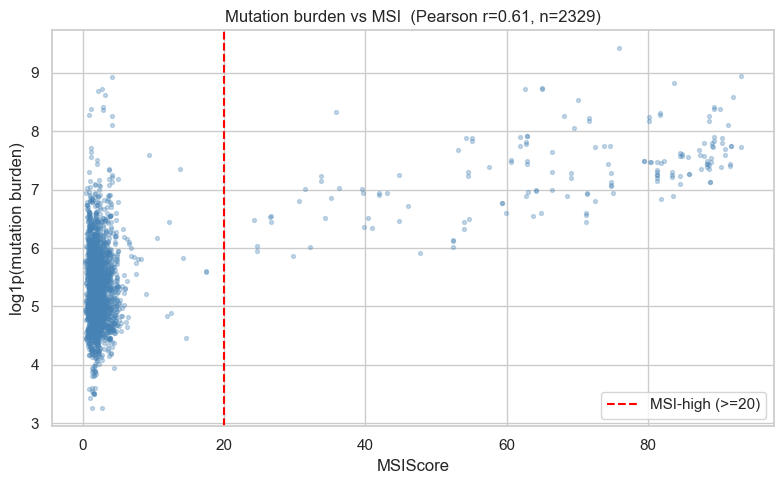

MSI-high median burden: 1607  |  MSI-low median burden: 190


In [20]:
import __init__ as ini
burden = df.groupby("ProfileID").size()
drv = df[df.HessDriver==True].groupby("ProfileID")["HugoSymbol"].nunique()
print(f"Driver genes per profile: median {int(drv.median())}, max {int(drv.max())}")
d8  = pd.read_csv(ini.df8,  usecols=["ProfileID","ModelID"])
d14 = pd.read_csv(ini.df14, usecols=["ModelID","MSIScore","IsDefaultEntryForModel"])
msi = d14[d14.IsDefaultEntryForModel=="Yes"].set_index("ModelID")["MSIScore"]
p2m = d8.drop_duplicates("ProfileID").set_index("ProfileID")["ModelID"].to_dict()
b = burden.rename("burden").to_frame()
b["msi"] = b.index.map(p2m).map(msi)
b = b.dropna(subset=["msi"])
r = np.corrcoef(np.log1p(b.burden), b.msi)[0,1]
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(b.msi, np.log1p(b.burden), s=8, alpha=0.3, color="steelblue")
ax.axvline(20, color="red", ls="--", label="MSI-high (>=20)")
ax.set_xlabel("MSIScore"); ax.set_ylabel("log1p(mutation burden)"); ax.legend()
ax.set_title(f"Mutation burden vs MSI  (Pearson r={r:.2f}, n={len(b)})")
plt.tight_layout(); plt.show()
print(f"MSI-high median burden: {int(b[b.msi>=20].burden.median())}  |  "
      f"MSI-low median burden: {int(b[b.msi<20].burden.median())}")

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
Every cancer cell's DNA is full of **typos** — small changes to the genetic code called **mutations** (specifically *somatic* mutations: i.e., acquired during the cancer's life, not inherited). Most typos are harmless background noise, but a handful are the **real drivers** that make the cell cancerous. This file is a massive catalogue of those typos: **over 1 million rows**, one per detected mutation.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **1,066,869 mutation rows** across **2,828 measurement profiles** (keyed by `ProfileID`, a measurement-run ID — not a cell line).
- A typical profile has **~194 mutations** (the "mutation burden"); a few "hypermutator" lines have tens of thousands.
- Helpful built-in flags: **`HessDriver`** marks the true cancer-driver typos (only ~0.33% of all rows), and **`VepImpact`** rates severity (~84% MODERATE, ~16% HIGH).
- High mutation burden links to **MSI** (microsatellite instability — i.e., a "broken spell-checker" state that lets typos pile up).
- ~19 columns are **>90% empty** (drop candidates); ~82% of profiles reach the master catalogue.

Next steps (preprocessing):
- **Map `ProfileID` → `ModelID`** via the OmicsProfiles bridge (df8).
- **Drop the ~19 mostly-empty columns.**
- **Collapse the million rows into per-cell-line features**, e.g.: total mutation burden, and **yes/no flags for mutations in specific driver genes** (using `HessDriver` and keeping HIGH/MODERATE impact).

Still missing in EDA:
- **Decide which gene panel matters** for the include/exclude use case — researchers will ask about specific genes, so we should pre-build flags for the genes that matter most.

### 3. Which ML approach fits this dataset
**Feature engineering → supervised.** Mutation flags are some of the **most interpretable "why this cell line" signals** available ("selected because it carries a driver mutation in gene X"), making them ideal inputs for an explainable ranking model.

> **Big-picture note:** Mutations are one of the four **core layers** on the DepMap spine that define the ~1,400-line training core.